# Face Detection with Haar Cascades
# Name: SHARVESHWARAN M
# Reg.No: 212224240150

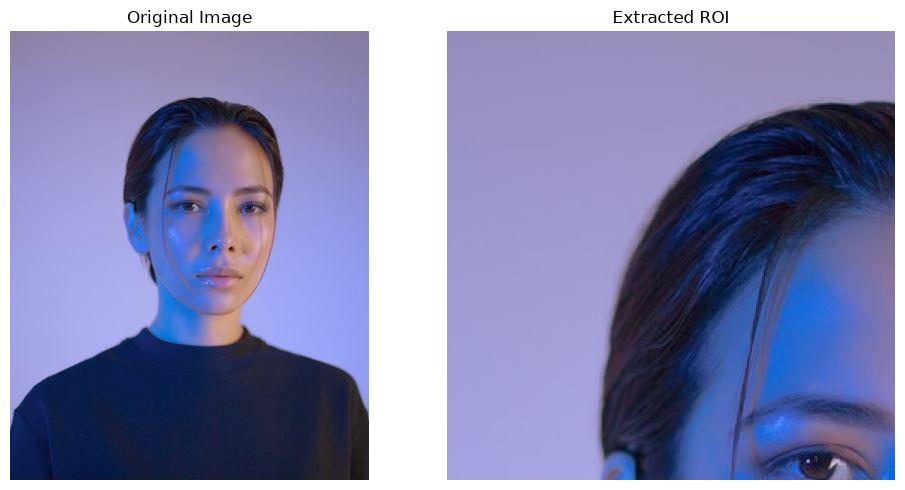

In [19]:
import cv2
import matplotlib.pyplot as plt

# Load sample image
image_path = 'sample.jpg'  # Replace with your image file path
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Define ROI coordinates (y_start:y_end, x_start:x_end)
# Adjust these bounds to crop your specific region (e.g., face, object)
roi = img_rgb[100:400, 150:450]

# Display Original and ROI
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_rgb)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(roi)
axes[1].set_title("Extracted ROI")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [20]:
import cv2
import matplotlib.pyplot as plt
from IPython.display import clear_output
import os
import urllib.request

cascade_file = 'haarcascade_frontalface_default.xml'
cascade_url = 'https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml'

if not os.path.exists(cascade_file):
    urllib.request.urlretrieve(cascade_url, cascade_file)

face_cascade = cv2.CascadeClassifier(cascade_file)

if face_cascade.empty():
    print("Error: Could not load face cascade classifier.")

cap = cv2.VideoCapture(0)

try:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            print("Failed to capture frame from webcam or camera unavailable.")
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.2, minNeighbors=5, minSize=(50, 50))
        
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        for (x, y, w, h) in faces:
            cv2.rectangle(frame_rgb, (x, y), (x + w, y + h), (255, 0, 0), 3)
            cv2.putText(frame_rgb, 'Face Detected', (x, y - 10), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

        plt.figure(figsize=(8, 6))
        plt.imshow(frame_rgb)
        plt.title(f"Real-Time Face Detection | Faces Count: {len(faces)} (Interrupt cell to stop)")
        plt.axis("off")
        plt.show()

        clear_output(wait=True)

except KeyboardInterrupt:
    print("Video stream stopped by user.")

finally:
    cap.release()

Video stream stopped by user.


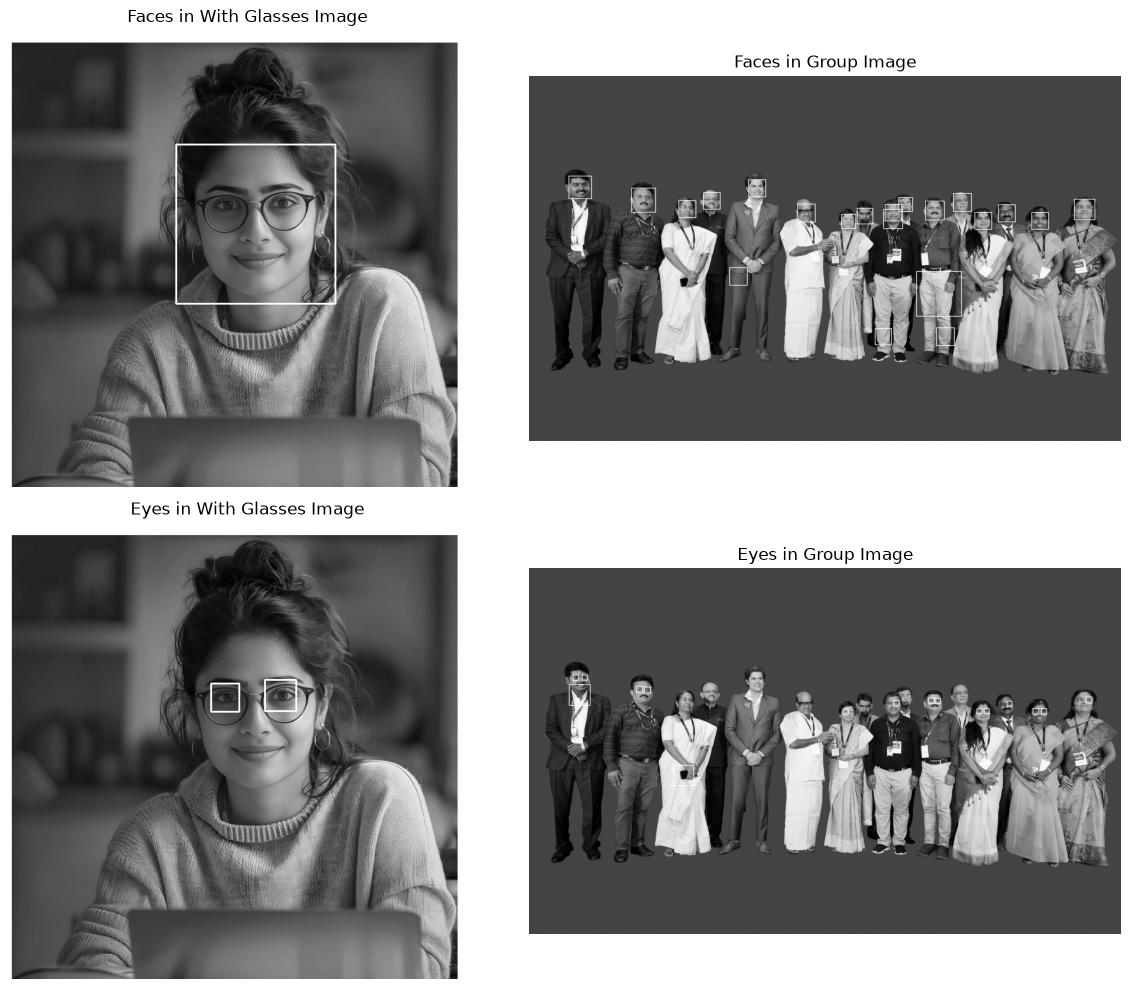

In [22]:
import cv2
import matplotlib.pyplot as plt
import os
import urllib.request

# 1. Download reference cascade XML files and test images
files_to_download = {
    'haarcascade_frontalface_default.xml': 'https://raw.githubusercontent.com/Bindhujaa02/Face-Detection-with-Haar-Cascades/main/haarcascade_frontalface_default.xml',
    'haarcascade_eye.xml': 'https://raw.githubusercontent.com/Bindhujaa02/Face-Detection-with-Haar-Cascades/main/haarcascade_eye.xml',
    'image_02.png': 'https://raw.githubusercontent.com/Bindhujaa02/Face-Detection-with-Haar-Cascades/main/image_02.png',
    'image_03.png': 'https://raw.githubusercontent.com/Bindhujaa02/Face-Detection-with-Haar-Cascades/main/image_03.png'
}

for filename, url in files_to_download.items():
    if not os.path.exists(filename):
        urllib.request.urlretrieve(url, filename)
        print(f"Downloaded {filename} successfully!")

# 2. Load Classifiers locally
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier('haarcascade_eye.xml')

if face_cascade.empty():
    raise IOError("Error loading face cascade XML file")
if eye_cascade.empty():
    raise IOError("Error loading eye cascade XML file")

# 3. Load Grayscale Images
withglass = cv2.imread('image_02.png', 0)
group = cv2.imread('image_03.png', 0)

# 4. Detection Functions
def detect_face(img, scaleFactor=1.1, minNeighbors=5):
    face_img = img.copy()
    face_rects = face_cascade.detectMultiScale(face_img, scaleFactor=scaleFactor, minNeighbors=minNeighbors)
    for (x, y, w, h) in face_rects:
        cv2.rectangle(face_img, (x, y), (x + w, y + h), (255, 255, 255), 2)
    return face_img

def detect_eyes(img):
    face_img = img.copy()
    eyes = eye_cascade.detectMultiScale(face_img)
    for (x, y, w, h) in eyes:
        cv2.rectangle(face_img, (x, y), (x + w, y + h), (255, 255, 255), 2)
    return face_img

# 5. Display Results
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(detect_face(withglass), cmap='gray')
axes[0, 0].set_title("Faces in With Glasses Image")
axes[0, 0].axis("off")

axes[0, 1].imshow(detect_face(group), cmap='gray')
axes[0, 1].set_title("Faces in Group Image")
axes[0, 1].axis("off")

axes[1, 0].imshow(detect_eyes(withglass), cmap='gray')
axes[1, 0].set_title("Eyes in With Glasses Image")
axes[1, 0].axis("off")

axes[1, 1].imshow(detect_eyes(group), cmap='gray')
axes[1, 1].set_title("Eyes in Group Image")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()